Purpose: To explore the Bhutan basin boundary from the Bhutan NSDI System website.

Install libraries </bt>
- here on the notebook or 
- from terminal within a python virtual environment<br/>

For Notebook option <br/>
 ```
 !pip install --upgrade pip
 !pip install -r requirements.txt
 ``` 
<br/>

For terminal option <br/>
open up a new terminal for instance in a VSCode environment
```
> python -m venv bb_venv <br/>
> bb_venv\Scripts\activate.bat <br/>
(bb_venv)> python -m pip install --upgrade pip  <br/>
(bb_venv)> pip install -r requirements.txt <br/>
```
<br/>


**NOTE:First time run, you need to choose the python environment and it might install ipykernel as well**

In [1]:
!pip install --upgrade pip
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


**Import Libraries**

In [2]:
import os

# from arcgis.gis import GIS
import pandas as pd
# from arcgis.features import GeoAccessor, FeatureLayer
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt 

import json
import re
from functools import reduce

from pyproj import CRS


arcgis - needs the following libraries installed
- arcgis
- shapely or fiona (I just installed both)
- geopandas
- arcpy
- pyproj
- rtree

NOTE: But for this notebook we aren't using as some features need paid version of ARCGIS.



In [3]:
cwd = os.getcwd()
cwd


'c:\\PS\\Projects\\Omdena\\bhutan_climate_modeling\\basin_border'

##### **Explore Bhutan Basin data**

**Inpect .prj file of Basin boundary, to check the CRS used, if present**

In [4]:
with open("./data/Basin boundary.prj", "r") as prj_file:
    prj_text = prj_file.read()

In [5]:
# check if prj_text holds the content of 'Bhutan boundary.prj' file
crs = CRS(prj_text)
epsg = crs.to_epsg()
print(f"Name: {crs.name}")
print(f"Coordinate system: {crs.coordinate_system}")
print(f"Area of Use: {crs.area_of_use}")
print(f"EPSG Code (if available): {epsg}")

Name: WGS 84 / Pseudo-Mercator
Coordinate system: cartesian
Area of Use: None
EPSG Code (if available): 3857


**Load the previously downloaded Bhutan - basin boundary data as a .shp file**

In [6]:
boun_shp_file = "./data/Basin boundary.shp"

In [7]:
# # Option 1: Load shp file as shown here by setting the fiona
# #           SHAPE config 
# # Set geoPandas - fiona engine SHAPE config options
# gdf_orig = None
# with fiona.Env(SHAPE_RESTORE_SHX='YES'):
#     # load the shp file
#     gdf_orig = gpd.read_file(boun_shp_file)
#     print(f"Total rows of basin boundary available: {gdf_orig.shape[0]}")
# gdf_orig.head(2)

In [8]:
# Option 2: directly load the shape file with fiona
gdf_orig = None
# NOTE: features are the rows from the shp file
# Refer: https://gis.stackexchange.com/questions/448450/getting-the-number-of-features-in-shapefile-without-opening-it-using-python
#
# If we have arcgis account then we can use, similar to below link...
# Refer: https://gis.stackexchange.com/questions/381120/convert-arcgis-spatially-enabled-dataframe-to-geopandas-geodataframe

# load shp file
with fiona.open(boun_shp_file) as features:
    print(f"Total features in basin boundary .shp file: {len(features)}")

    gdf_orig = gpd.GeoDataFrame.from_features(features)
    print(f"Loaded geoDataFrame shape: {gdf_orig.shape}")
    print(f"crs: {gdf_orig.crs}")
gdf_orig.head(2)


Total features in basin boundary .shp file: 10
Loaded geoDataFrame shape: (10, 7)
crs: None


,geometry,basin,path,area_ha,area_sqkm,SHAPE__Len,SHAPE__Are
0,"POLYGON ((10058028.821 3151062.425, 10058067.6...",Aiechhu,E:\2024-2025\Basin_boundaries\Aiechhu.shp,196390.588555,1963.905886,337019.366034,2.481073e+09
1,"POLYGON ((10245694.293 3155611.158, 10245655.4...",Merak_Sakteng,E:\2024-2025\Basin_boundaries\Merak-Sakteng.shp,13881.067718,138.810677,76767.739616,1.763939e+08


In [9]:
# Set the correct CRS from the .prj file (Web Mercator)
# gdf_orig.set_crs(epsg=3857, inplace=True) 
# gdf_orig.set_crs(epsg=crs.to_epsg(), inplace=True)
gdf_orig.set_crs(epsg=epsg, inplace=True)

# Reproject to WGS84 (EPSG:4326)
gdf_wgs84 = gdf_orig.to_crs("EPSG:4326")

# Calculate centroids in WGS84
centroids = gdf_wgs84.geometry.centroid

# Extract longitude and latitude
gdf_wgs84['longitude'] = centroids.x
gdf_wgs84['latitude'] = centroids.y

# Print the range
print(f"Longitude range: {gdf_wgs84['longitude'].min()} to {gdf_wgs84['longitude'].max()}")
print(f"Latitude range: {gdf_wgs84['latitude'].min()} to {gdf_wgs84['latitude'].max()}")
print(gdf_wgs84[['basin', 'longitude', 'latitude']].head())


Longitude range: 88.9878498499434 to 92.03395801646504
Latitude range: 26.945873636088635 to 27.84243536003244
           basin  longitude   latitude
0        Aiechhu  90.464808  26.945874
1  Merak_Sakteng  92.033958  27.329946
2     Mangdechhu  90.649025  27.506149
3      Jaldhakha  88.987850  27.061616
4        Amochhu  89.120110  27.350269


C:\Users\Pankaja\AppData\Local\Temp\ipykernel_24212\409093198.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_wgs84.geometry.centroid


**Visualize the geoDataFrame**

In [10]:
# just check the crs before visualizing to make sure it is WGS84
gdf_wgs84.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

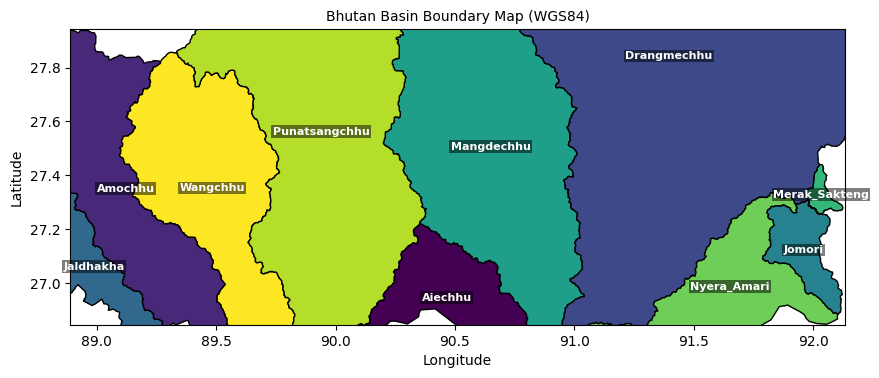

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot the basin polygons (not points)
# gdf_wgs84.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black', legend=True)
gdf_wgs84.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black')

# Add basin name labels at centroid positions
for idx, row in gdf_wgs84.iterrows():
    ax.text(row['longitude'], row['latitude'], row['basin'],
            horizontalalignment='center', verticalalignment='center',
            fontsize=8, color='white', weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.title("Bhutan Basin Boundary Map (WGS84)", fontsize=10)

# Set axis limits to the extent of your data
ax.set_xlim(gdf_wgs84['longitude'].min()-0.1, gdf_wgs84['longitude'].max()+0.1)
ax.set_ylim(gdf_wgs84['latitude'].min()-0.1, gdf_wgs84['latitude'].max()+0.1)

plt.show()



##### **Explore the Discharge distribution**

In [12]:
# load discharge file
d_file = "./data/Discharge data Major Basin.xlsx"

disc_sheets = pd.ExcelFile(d_file, engine="openpyxl")
disc_sheet_names = list(disc_sheets.sheet_names)
disc_sheet_names


['Lungtenphu (Wangchhu)',
 'Wangdi rapid (Punatshangchhu)',
 'Pangbang dangmechhu',
 'tingtibi (Mangdichhu)',
 'Kurjey (Chamkharchhu)']

**Scripts**

In [13]:
# **************************************************************************
# Below function from Qingfang - repurposed here
# **************************************************************************
def load_station_sheet(xlsx_path: str, sheet_name: str, skiprows: int = 3):
    """
    Load one sheet (station) and do minimal cleaning:
      - Skip metadata rows (default: 3)
      - Trim column names; harmonize 'water Level' -> 'Water Level' if present
      - Parse 'Date' to datetime
      - Coerce 'Flow' and 'Water Level' to numeric
      - Drop entirely-empty columns
      - Sort by 'Date'
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name, skiprows=skiprows)
    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    if "water Level" in df.columns and "Water Level" not in df.columns:
        df = df.rename(columns={"water Level": "Water Level"})
    if "Date" not in df.columns:
        raise ValueError(f"'Date' column not found in sheet: {sheet_name}")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Flow", "Water Level"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    keep = [c for c in ["Date", "Flow", "Water Level"] if c in df.columns]
    df = df[keep].dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    return df



In [14]:
# **************************************************************************
#   Pankaja Shankar - functions
# **************************************************************************
# Function to convert deg,mins,secs to decimal Degrees
def dms_to_decimal_degrees(dms_string):
    d_arr = re.split(r'[: ]', dms_string)
    degrees = float(d_arr[0] or "0")
    minutes = float(d_arr[1] or "0")
    seconds = float(d_arr[2] or "0")
    direction = d_arr[3]

    decimal_degrees = degrees + (minutes / 60) + (seconds / 3600)

    # adjust for South or West hemispheres
    if direction == 'S' or direction == 'W':
        decimal_degrees *= -1  

    return decimal_degrees

def extract_worksheet_location_details(file_path="", sheet_name=""):
    # extract information from first 3 rows and the columns
    df_hdr_orig = pd.read_excel(file_path, sheet_name=sheet_name)
    df_hdr = df_hdr_orig[0:3]
    # parse colon_values
    parsed_loc = {
        item.split(' : ')[0].strip(): (
            item.split(' : ')[1].strip()
        )
        for item in df_hdr.columns if "Unnamed" not in item
    }
    # convert the dictionary to a JSON object
    loc = json.loads(json.dumps(parsed_loc, indent=4)) # indent for readable JSON

    # print(loc)
    # next get other details
    loc_coords_arr = [
        cell_value
        for row in df_hdr.itertuples(index=False)
        for cell_value in row
        if isinstance(cell_value, str) and ":" in cell_value
    ]
    # loc_coords
    # parse loc_coords
    parsed_data = {
        item.split(' : ')[0].strip(): (
            dms_to_decimal_degrees(item.split(' : ')[1].strip())  # Process Latitude and Longitude
            if item.split(' : ')[0].strip() in ['Latitude', 'Longitude'] else
            float(item.split(' : ')[1].replace(' metres', '').replace(' sq km', '').strip()) # Process Elevation and Area
        )
        for item in loc_coords_arr
    }

    # convert the dictionary to a JSON object
    loc_coords = json.loads(json.dumps(parsed_data, indent=4)) # indent for readable JSON

    loc_details = {}
    loc_details["Station Name"] = loc["Station Name"]
    loc_details["Latitude"] = loc_coords['Latitude']
    loc_details["Longitude"] = loc_coords['Longitude']
    loc_details["Elevation"] = loc_coords["Elevation"]
    loc_details["Area"] = loc_coords["Area"]
    # print(loc_details)

    return loc_details

def load_worksheet_extract_data_and_combine(file_path="", sheet_name=""):
    step = ""
    df_data = None

    try:        
        step = " extract header details "
        location_details = extract_worksheet_location_details(file_path=file_path, sheet_name=sheet_name)
        step = " extract datarows "
        df_dtls_orig = load_station_sheet(d_file, sheet_name=sheet_name)

        step = " combine details w datarows "
        df_data = df_dtls_orig.copy(deep=True)
        df_data.insert(0, "Station Name", location_details['Station Name'])
        df_data.insert(1, "Latitude", location_details['Latitude'])
        df_data.insert(2, "Longitude", location_details['Longitude'])
        df_data.insert(3, "Elevation", location_details['Elevation'])
        df_data.insert(4, "Area", location_details['Area'])
    except Exception as ex:
        print(f"Error occurred with exception: {ex} at step: {step}")

    return df_data 

def combine_data_from_worksheets(file_path=""):
    df_combined = None
    status = False
    dfs = []
    step = ""

    try:        
        cnt = 0
        step = " extract sheet "
        for sheet_name in disc_sheet_names:
            df = load_worksheet_extract_data_and_combine(file_path=d_file, sheet_name=sheet_name)
            print(f"{sheet_name} data: {df.shape}")
            dfs.append(df)
            cnt += 1
        step = " combine "
        # df_combined = pd.concat(dfs, axis=1)
        df_combined_orig = reduce(lambda l,r: pd.concat([l, r], ignore_index=True), dfs)
        df_combined = df_combined_orig.drop_duplicates().reset_index(drop=True)

        step = " colnames lower "
        df_combined.columns = df_combined.columns.str.lower()
        status = True
    except Exception as ex:
        print(f"Error occurred with exception: {ex} at step: {step}")

    return status, df_combined



**Combine data from worksheets of Discharge spreadsheet**

In [15]:
combine_status, df_discharge = combine_data_from_worksheets(file_path=d_file)
print(f"df_dist shape: {df_discharge.shape}")
df_discharge.head(4)

Lungtenphu (Wangchhu) data: (12308, 8)
Wangdi rapid (Punatshangchhu) data: (8766, 8)
Pangbang dangmechhu data: (4748, 8)
tingtibi (Mangdichhu) data: (6763, 8)
Kurjey (Chamkharchhu) data: (8766, 8)
df_dist shape: (41351, 8)


,station name,latitude,longitude,elevation,area,date,flow,water level
0,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-22,5.655,NaN
1,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-23,6.107,0.3450
2,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-24,6.195,0.3525
3,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-25,6.404,0.3575


**Proceed to visualize by superimposing the discharge on the basin regions**

In [16]:
from shapely.geometry import Point

In [17]:
epsg

3857

In [18]:
def plot_combined_basin_and_discharge(gdf_basin=None, df_disch=None):

    # Convert df_dist to GeoDataFrame
    gdf_disch_points = gpd.GeoDataFrame(
        df_disch,
        geometry=gpd.points_from_xy(df_disch['longitude'], df_disch['latitude']),
        crs="EPSG:4326"
    )
    # join the discharge points with gdf_basin
    joined = gpd.sjoin(gdf_disch_points, gdf_basin, predicate="within", how="inner")

    # select and rename merged latitude/longitude columns
    merged_latlngs = joined.rename(
            columns={
                'latitude_left': 'latitude',
                'longitude_left': 'longitude',
                'latitude_right': 'basin_latitude',
                'longitude_right': 'basin_longitude'
            }
    )[['station name', 'flow', 'water level', 'longitude', 'latitude', 'basin', 'geometry']]

    # print(merged_latlngs.head())

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    # Plot the basin polygons (not points) 
    # gdf_basin.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black', legend=True)
    gdf_basin.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black')

    # Add basin name labels at centroid positions
    for idx, row in gdf_basin.iterrows():
        ax.text(row['longitude'], row['latitude'], row['basin'],
                horizontalalignment='center', verticalalignment='center',
                fontsize=8, color='white', weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    sc = ax.scatter(
        merged_latlngs['longitude'], merged_latlngs['latitude'],
        # multiply or divide by a factor, multiplying increases the point size we don't want that
        s=merged_latlngs['flow']/4,   
        c=merged_latlngs['flow'], cmap='cool', alpha=0.7, edgecolor='white'
    )
    plt.colorbar(sc, ax=ax, label='Discharge (Flow)', shrink=0.5)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.title("Bhutan Basin Boundary - Discharge Points Within Basins", fontsize=10)
    plt.show()


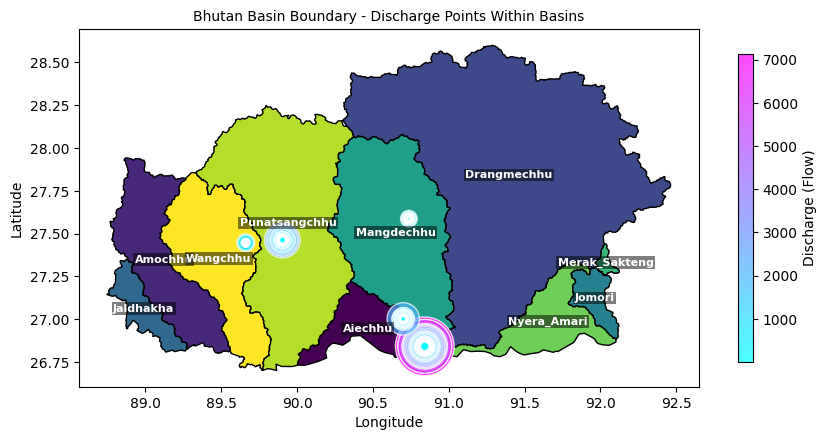

In [19]:
# plot 
plot_combined_basin_and_discharge(gdf_basin=gdf_wgs84, df_disch=df_discharge)